# Project 02 (medium): CNN image classification with PyTorch — an architecture and regularization ablation

**Goal:** From NumPy (project 01) to PyTorch. You build a CNN for **Fashion-MNIST** (70,000 real product images from Zalando, 10 classes, 28×28 greyscale) and answer three questions from the script experimentally:

1. **Architecture:** how much does the inductive bias of a CNN buy (locality + weight sharing, script 2.5) compared with an MLP that has *more* parameters?
2. **Regularization:** what do dropout, weight decay (AdamW) and data augmentation (script 2.3) change about the learning curves and the test error?
3. **Optimizer:** Adam vs. SGD+momentum (script 2.1) at an identical budget.

The methodological standard: an **ablation study** — only *one* factor is ever changed against a reference, otherwise you do not know what caused the difference.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms

torch.manual_seed(42)
np.random.seed(42)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Computing on:", device)

DATA_DIR = "datasets"   # torchvision downloads here (excluded from the repository via .gitignore)

# Normalization with the known Fashion-MNIST statistics (mean/std of the training pixels)
normalize = transforms.Normalize((0.2860,), (0.3530,))
tf_plain = transforms.Compose([transforms.ToTensor(), normalize])
tf_augment = transforms.Compose([
    transforms.RandomCrop(28, padding=2),          # random shift of up to 2 pixels
    transforms.RandomHorizontalFlip(),             # mirroring (a valid invariance for clothes)
    transforms.ToTensor(), normalize,
])

train_plain = torchvision.datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=tf_plain)
train_aug   = torchvision.datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=tf_augment)
test_set    = torchvision.datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=tf_plain)

# For the ablation we use 20k of the 60k training images — the same conclusions, 1/3 of the compute.
# (For peak performance at the end, simply set SUBSET to 60000.)
SUBSET = 20000
idx = torch.randperm(len(train_plain), generator=torch.Generator().manual_seed(0))[:SUBSET]

def make_loader(ds, train=True):
    if train:
        return DataLoader(Subset(ds, idx.tolist()), batch_size=128, shuffle=True)
    return DataLoader(ds, batch_size=512, shuffle=False)

loader_plain = make_loader(train_plain)
loader_aug = make_loader(train_aug)
loader_test = make_loader(test_set, train=False)

CLASSES = train_plain.classes
print(f"{SUBSET} training images, {len(test_set)} test images, classes: {CLASSES}")

Computing on: mps
20000 training images, 10000 test images, classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


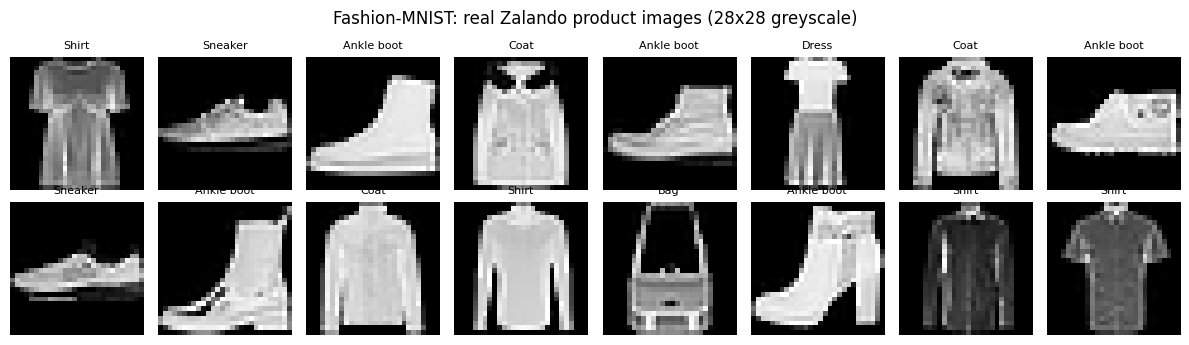

In [2]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
raw = torchvision.datasets.FashionMNIST(DATA_DIR, train=True, download=True)  # without transform, for the eye
for ax, i in zip(axes.ravel(), range(16)):
    img, label = raw[int(idx[i])]
    ax.imshow(img, cmap="gray"); ax.set_title(CLASSES[label], fontsize=8); ax.axis("off")
plt.suptitle("Fashion-MNIST: real Zalando product images (28x28 greyscale)")
plt.tight_layout(); plt.show()

## Step 1: The contenders — MLP vs. CNN

**MLP baseline:** $784 \to 256 \to 128 \to 10$, ReLU. Number of parameters: $785{\cdot}256 + 257{\cdot}128 + 129{\cdot}10 \approx 235\,000$.

**CNN:** two blocks `[Conv3×3 → BatchNorm → ReLU] ×2 → MaxPool2×2` with 32 and 64 channels respectively, then **global average pooling** → dropout → Linear(64→10). Following script 2.5: the number of parameters of the convolutions is *independent* of the image size; GAP saves the fat dense layer. Work it out: the CNN has only $\approx 66\,000$ parameters — **3.5 times fewer than the MLP**.

The receptive field at the end of the network (script 2.5, with the two pools as stride-2 stages): every neuron of the last conv layer sees a $22{\times}22$ window of the input image — almost the whole image, as it should be.

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


def conv_block(c_in, c_out):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, kernel_size=3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
        nn.Conv2d(c_out, c_out, kernel_size=3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
        nn.MaxPool2d(2),
    )

class CNN(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(conv_block(1, 32), conv_block(32, 64))  # 28x28 -> 14x14 -> 7x7
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),   # global average pooling: (B,64,7,7) -> (B,64)
            nn.Dropout(dropout),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.head(self.features(x))


def n_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"MLP: {n_params(MLP()):>7,} parameters")
print(f"CNN: {n_params(CNN()):>7,} parameters")

MLP: 235,146 parameters
CNN:  66,026 parameters


## Step 2: The training and evaluation loop

The standard PyTorch cycle per batch: `zero_grad()` → forward → loss → `backward()` (that is *exactly* your project 01 code, only differentiated automatically) → `step()`.

Two pitfalls from the script that become real here:
- `model.train()` / `model.eval()`: switches **dropout** and **BatchNorm** (batch statistics vs. running averages, script 2.4). Evaluating in training mode gives systematically wrong numbers.
- `nn.CrossEntropyLoss` expects **raw logits** (the log-sum-exp trick internally, script 1.3) — no softmax in the model!

In [4]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()                                   # IMPORTANT: BatchNorm to running averages, dropout off
    loss_sum, correct, n = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss(reduction="sum")
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss_sum += criterion(logits, yb).item()
        correct += (logits.argmax(dim=1) == yb).sum().item()
        n += yb.numel()
    return loss_sum / n, correct / n

def train_model(model, opt, train_loader, epochs=3, log=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "test_loss": [], "test_acc": []}
    for epoch in range(1, epochs + 1):
        model.train()
        running, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            opt.step()
            running += loss.item() * yb.numel(); n += yb.numel()
        te_loss, te_acc = evaluate(model, loader_test)
        hist["train_loss"].append(running / n)
        hist["test_loss"].append(te_loss)
        hist["test_acc"].append(te_acc)
        if log:
            print(f"  epoch {epoch}: train_loss={running/n:.4f}  test_loss={te_loss:.4f}  test_acc={te_acc:.4f}")
    return hist

## Step 3: The ablation

Four configurations, an identical budget (the same data, the same number of epochs):

| # | Model | Optimizer | Regularization | tests question |
|---|---|---|---|---|
| A | MLP (235k par.) | Adam ($10^{-3}$) | — | architectural bias |
| B | CNN (66k par.) | Adam ($10^{-3}$) | — | architectural bias |
| C | CNN | **AdamW** ($10^{-3}$, wd $5{\cdot}10^{-4}$) | dropout 0.3 + **augmentation** | regularization |
| D | CNN | **SGD+momentum** (0.1 / 0.9) | — | optimizer |

In [5]:
EPOCHS = 3
results = {}

configs = {
    "A: MLP + Adam":            (lambda: MLP(),            lambda m: torch.optim.Adam(m.parameters(), lr=1e-3),  loader_plain),
    "B: CNN + Adam":            (lambda: CNN(dropout=0.0), lambda m: torch.optim.Adam(m.parameters(), lr=1e-3),  loader_plain),
    "C: CNN + AdamW + reg/aug": (lambda: CNN(dropout=0.3), lambda m: torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=5e-4), loader_aug),
    "D: CNN + SGD momentum":    (lambda: CNN(dropout=0.0), lambda m: torch.optim.SGD(m.parameters(), lr=0.1, momentum=0.9), loader_plain),
}

models = {}
for name, (make_model, make_opt, loader) in configs.items():
    torch.manual_seed(7)                      # the same initialization where the architecture is the same
    print(name)
    t0 = time.time()
    model = make_model()
    results[name] = train_model(model, make_opt(model), loader, epochs=EPOCHS)
    models[name] = model
    print(f"  ({time.time() - t0:.0f} s)")

A: MLP + Adam


  epoch 1: train_loss=0.6325  test_loss=0.4734  test_acc=0.8260


  epoch 2: train_loss=0.4311  test_loss=0.4314  test_acc=0.8373


  epoch 3: train_loss=0.3763  test_loss=0.3990  test_acc=0.8532
  (4 s)
B: CNN + Adam


  epoch 1: train_loss=1.0008  test_loss=0.7117  test_acc=0.7787


...

  epoch 2: train_loss=0.7379  test_loss=0.6942  test_acc=0.7416


  epoch 3: train_loss=0.6337  test_loss=0.6195  test_acc=0.7752
  (13 s)
D: CNN + SGD momentum


  epoch 1: train_loss=0.8068  test_loss=0.6726  test_acc=0.7627


  epoch 2: train_loss=0.4965  test_loss=0.5364  test_acc=0.7970


  epoch 3: train_loss=0.3973  test_loss=0.4668  test_acc=0.8288
  (12 s)


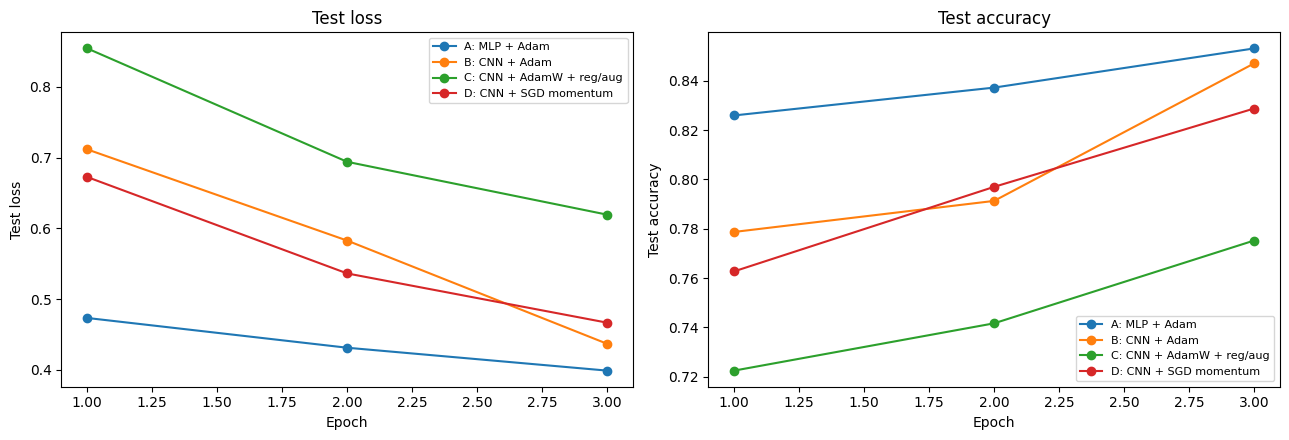

Configuration                 Parameters  Test acc
A: MLP + Adam                    235,146    0.8532
B: CNN + Adam                     66,026    0.8471
C: CNN + AdamW + reg/aug          66,026    0.7752
D: CNN + SGD momentum             66,026    0.8288


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, h in results.items():
    ep = range(1, EPOCHS + 1)
    axes[0].plot(ep, h["test_loss"], marker="o", label=name)
    axes[1].plot(ep, h["test_acc"], marker="o", label=name)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Test loss"); axes[0].set_title("Test loss"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Test accuracy"); axes[1].set_title("Test accuracy"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'Configuration':<28} {'Parameters':>11} {'Test acc':>9}")
for name, h in results.items():
    print(f"{name:<28} {n_params(models[name]):>11,} {h['test_acc'][-1]:>9.4f}")

**Interpretation (compare it with your numbers):**

- **A vs. B — and this is the actual lesson of the ablation:** after 3 epochs the MLP is still marginally *ahead* (about 0.853 vs. 0.847). The textbook expectation ("the CNN wins because of its inductive bias") does **not** show up at this budget, and it is worth understanding why: this CNN has a global-average-pooling head and BatchNorm, both of which converge more slowly than a dense MLP on 28×28 greyscale images, and 3 epochs on 20k images is a very short budget. What the CNN does deliver is the better ceiling per parameter — in step 5, over 10 epochs, the regularized CNN reaches about 0.861 with 3.5 times *fewer* parameters, while the MLP has essentially stopped improving. So the inductive bias does not buy faster progress per epoch; it buys a better result at a far smaller parameter budget. Read a 3-epoch snapshot as a snapshot, never as a verdict about architectures.
- **B vs. C:** after only 3 epochs the regularized variant is *not* yet ahead (0.775 vs. 0.847) — augmentation makes the training problem harder and only pays off over more epochs (regularization trades training fit for generalization). Measure the effect in step 5 with longer training.
- **B vs. D:** with a well chosen learning rate, SGD+momentum can keep up with Adam (for image classification it has historically often been better with long training); Adam is more robust against the choice of learning rate — exactly the trade-off from script 2.1.

## Step 4: Error diagnostics — where does the network go wrong?

Accuracy alone hides the structure of the errors. The confusion matrix plus the most confidently misclassified images show *which* classes the network confuses (classically: shirt ↔ t-shirt ↔ pullover — those are hard for humans too).

Best model: A: MLP + Adam


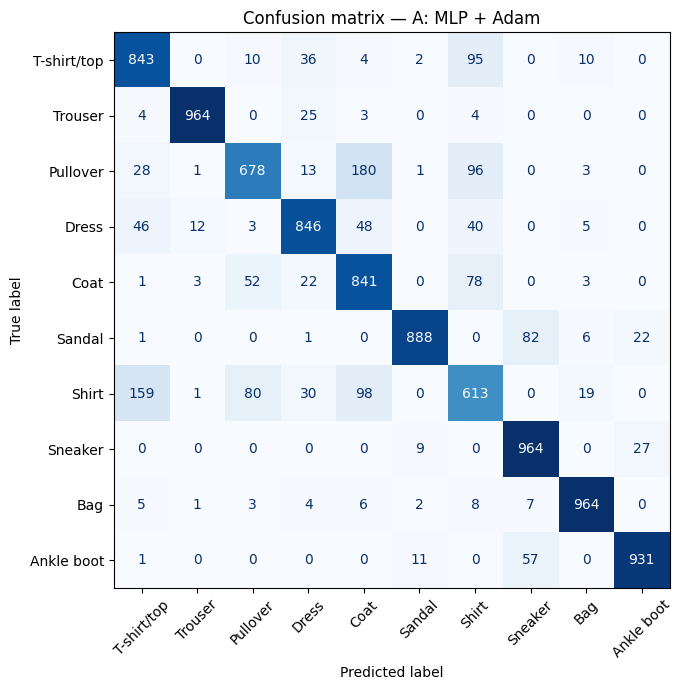

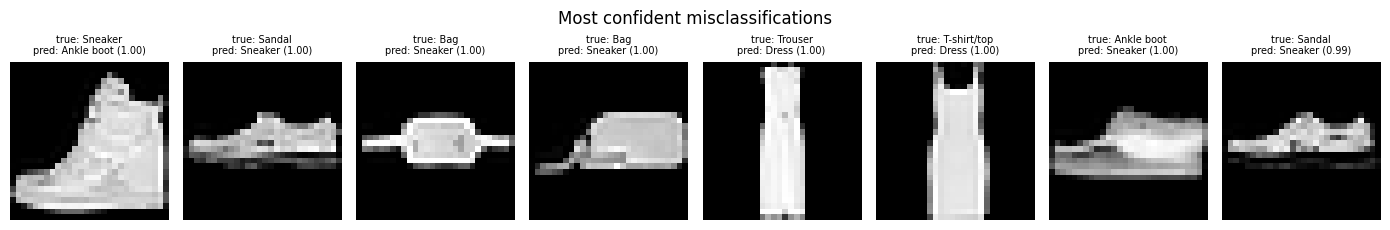

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_name = max(results, key=lambda k: results[k]["test_acc"][-1])
best = models[best_name]
print("Best model:", best_name)

best.eval()
all_logits, all_y = [], []
with torch.no_grad():
    for xb, yb in loader_test:
        all_logits.append(best(xb.to(device)).cpu())
        all_y.append(yb)
logits = torch.cat(all_logits); y_true = torch.cat(all_y)
y_pred = logits.argmax(dim=1)

fig, ax = plt.subplots(figsize=(7.5, 7))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASSES).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout(); plt.show()

# The "most self-assured" errors: wrong AND with high confidence
probs = logits.softmax(dim=1)
conf, _ = probs.max(dim=1)
wrong = (y_pred != y_true).nonzero().squeeze(1)
worst = wrong[conf[wrong].argsort(descending=True)][:8]
fig, axes = plt.subplots(1, 8, figsize=(14, 2.4))
for ax, i in zip(axes, worst.tolist()):
    img, _ = test_set[i]
    ax.imshow(img.squeeze() * 0.3530 + 0.2860, cmap="gray")
    ax.set_title(f"true: {CLASSES[y_true[i]]}\npred: {CLASSES[y_pred[i]]} ({conf[i]:.2f})", fontsize=7)
    ax.axis("off")
plt.suptitle("Most confident misclassifications"); plt.tight_layout(); plt.show()

## Step 5: Does regularization pay off over time?

The 3-epoch ablation is a snapshot. Now the real test from script 2.3: **the plain CNN vs. the CNN + reg/aug over 10 epochs.** The expectation: the unregularized network drives the train loss towards 0 faster, but its test loss stagnates or rises (the overfitting gap); the regularized variant learns more slowly and ends up better.

CNN plain


  final test acc: 0.8478
CNN + reg/aug


  final test acc: 0.8607


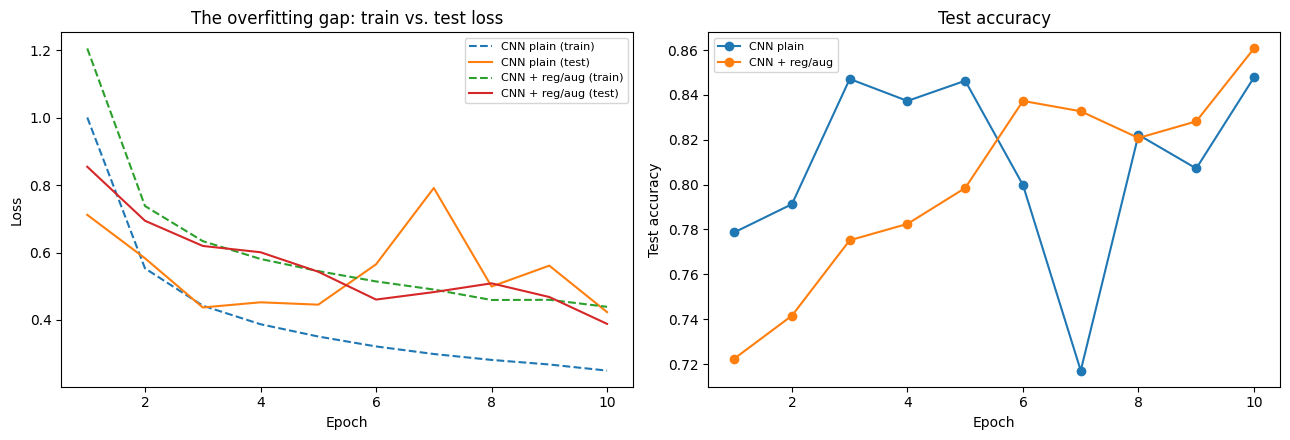

In [8]:
EPOCHS_LONG = 10
long_results = {}
for name, (make_model, make_opt, loader) in {
    "CNN plain":     configs["B: CNN + Adam"],
    "CNN + reg/aug": configs["C: CNN + AdamW + reg/aug"],
}.items():
    torch.manual_seed(7)
    print(name)
    model = make_model()
    long_results[name] = train_model(model, make_opt(model), loader, epochs=EPOCHS_LONG, log=False)
    print(f"  final test acc: {long_results[name]['test_acc'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, h in long_results.items():
    ep = range(1, EPOCHS_LONG + 1)
    axes[0].plot(ep, h["train_loss"], "--", label=f"{name} (train)")
    axes[0].plot(ep, h["test_loss"], label=f"{name} (test)")
    axes[1].plot(ep, h["test_acc"], marker="o", label=name)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("The overfitting gap: train vs. test loss"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Test accuracy"); axes[1].set_title("Test accuracy"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Conclusion

- **Inductive bias buys efficiency, not speed:** at a 3-epoch budget the 66k CNN does not yet beat the 235k MLP (0.847 vs. 0.853); over 10 epochs with regularization it ends up in front (0.861) with 3.5 times fewer parameters. Architecture encodes prior knowledge about the structure of the data — but that advantage has to be given the training time to materialize.
- **Regularization is an investment:** slower in the short run, a smaller train/test gap in the long run. Its effect *has* to be judged from learning curves, not from a single number.
- **`model.eval()` is not a formality:** BatchNorm and dropout behave fundamentally differently in training and at inference (script 2.3/2.4).
- **Ablation as a method:** only ever change one factor — this carries through all the following modules (and every real research paper).

**On to project 03:** unsupervised learning on real customer data — there are no labels there and hence no accuracy any more; validation becomes the actual challenge.